In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/advanced-dls-spring-2021/submission.csv
/kaggle/input/advanced-dls-spring-2021/train.csv
/kaggle/input/advanced-dls-spring-2021/test.csv


In [7]:
train_data = pd.read_csv('/kaggle/input/advanced-dls-spring-2021/train.csv')
test_data = pd.read_csv('/kaggle/input/advanced-dls-spring-2021/test.csv')

In [8]:
train_data.head()

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
0,55,19.50,1026.35,Male,0,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,0
1,72,25.85,1872.2,Male,0,Yes,No,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),0
2,1,75.90,75.9,Male,0,No,No,Yes,No,Fiber optic,No,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,1
3,32,79.30,2570,Female,1,Yes,No,Yes,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Mailed check,0
4,60,115.25,6758.45,Female,0,Yes,Yes,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),0


In [11]:
train_data.dtypes

ClientPeriod                  int64
MonthlySpending             float64
TotalSpent                   object
Sex                          object
IsSeniorCitizen               int64
HasPartner                   object
HasChild                     object
HasPhoneService              object
HasMultiplePhoneNumbers      object
HasInternetService           object
HasOnlineSecurityService     object
HasOnlineBackup              object
HasDeviceProtection          object
HasTechSupportAccess         object
HasOnlineTV                  object
HasMovieSubscription         object
HasContractPhone             object
IsBillingPaperless           object
PaymentMethod                object
Churn                         int64
dtype: object

In [130]:
for df in [train_data, test_data]:
    df['TotalSpent'] = df['TotalSpent'].apply(lambda val: float(val) if val != ' ' else 0)

In [121]:
train_data['Churn'].unique()

array([0, 1])

In [22]:
for df in [train_data, test_data]:
    print(df['Sex'].unique())
    print(df['Sex'].value_counts())
    df['Sex'] = df['Sex'].apply(lambda sex: 1 if sex=='Male' else 0)
    print()
    print(df['Sex'].unique())
    print(df['Sex'].value_counts())

['Male' 'Female']
Sex
Male      900
Female    861
Name: count, dtype: int64

[1 0]
Sex
1    900
0    861
Name: count, dtype: int64


In [36]:
for df in [train_data, test_data]:
    for column in ["HasPartner", "HasChild", "HasPhoneService", "HasMultiplePhoneNumbers", "IsBillingPaperless"]:
        df[column] = df[column].apply(lambda val: 1 if val.lower() == "yes" else 0)

In [31]:
train_data['HasInternetService'].unique(), test_data['HasInternetService'].unique() 

(array(['No', 'Fiber optic', 'DSL'], dtype=object),
 array(['DSL', 'Fiber optic', 'No'], dtype=object))

In [33]:
train_data['HasOnlineBackup'].unique(), train_data['PaymentMethod'].unique()

(array(['No internet service', 'No', 'Yes'], dtype=object),
 array(['Mailed check', 'Credit card (automatic)', 'Electronic check',
        'Bank transfer (automatic)'], dtype=object))

In [37]:
train_data.head()

,ClientPeriod,MonthlySpending,TotalSpent,Sex,IsSeniorCitizen,HasPartner,HasChild,HasPhoneService,HasMultiplePhoneNumbers,HasInternetService,HasOnlineSecurityService,HasOnlineBackup,HasDeviceProtection,HasTechSupportAccess,HasOnlineTV,HasMovieSubscription,HasContractPhone,IsBillingPaperless,PaymentMethod,Churn
0,55,19.50,1026.35,1,0,1,1,1,0,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,0,Mailed check,0
1,72,25.85,1872.2,1,0,1,0,1,1,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Credit card (automatic),0
2,1,75.90,75.9,1,0,0,0,1,0,Fiber optic,No,No,No,Yes,No,No,Month-to-month,1,Electronic check,1
3,32,79.30,2570,0,1,1,0,1,1,Fiber optic,No,No,Yes,No,No,No,Month-to-month,0,Mailed check,0
4,60,115.25,6758.45,0,0,1,1,1,1,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,0,Credit card (automatic),0


In [39]:
from sklearn.preprocessing import OneHotEncoder

In [132]:
cat_ftr = ['HasInternetService', 'HasOnlineSecurityService', 'HasOnlineBackup', 'HasDeviceProtection', 'HasTechSupportAccess', 
          'HasOnlineTV', 'HasMovieSubscription', 'HasContractPhone', 'PaymentMethod']
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown="ignore").fit(train_data[cat_ftr])

In [131]:
num_ftr = list(set(train_data.columns) - set(cat_ftr + ["Churn"]))
print(num_ftr)

['IsBillingPaperless', 'IsSeniorCitizen', 'HasMultiplePhoneNumbers', 'HasPhoneService', 'MonthlySpending', 'ClientPeriod', 'Sex', 'HasChild', 'TotalSpent', 'HasPartner']


In [133]:
X_train = np.hstack([train_data[num_ftr].to_numpy(), ohe.transform(train_data[cat_ftr])])
y_train = train_data["Churn"]

In [134]:
X_test = np.hstack([test_data[num_ftr].to_numpy(), ohe.transform(test_data[cat_ftr])])

In [210]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score as acc
from xgboost import XGBClassifier

In [203]:
model1 = RandomForestClassifier(max_depth=10, n_estimators=1000).fit(X_train, y_train)

In [204]:
acc(model1.predict(X_train), y_train)

0.8663385081408558

In [205]:
y_pred = model1.predict_proba(X_test)[:, 1]
y_pred

array([0.06838308, 0.6240692 , 0.61683134, ..., 0.7990313 , 0.56920867,
       0.00551271])

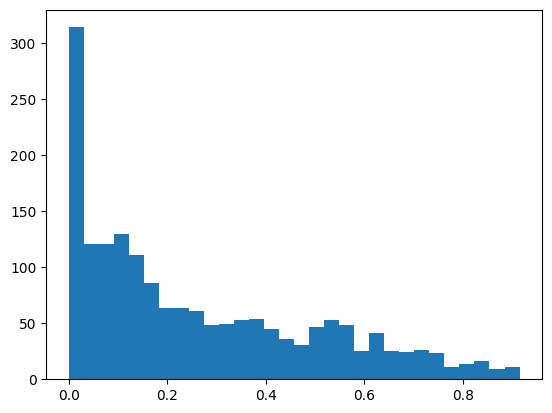

In [206]:
import matplotlib.pyplot as plt
plt.hist(y_pred, bins=30)
plt.show()

In [207]:
import pandas as pd
sub = pd.DataFrame({"Id": test_data.index, "Churn": y_pred})
sub

,Id,Churn
0,0,0.068383
1,1,0.624069
2,2,0.616831
3,3,0.022869
4,4,0.000848
...,...,...
1756,1756,0.157725
1757,1757,0.006242
1758,1758,0.799031
1759,1759,0.569209


In [208]:
sub.to_csv("submission_random_forest_7.csv", index=False)

In [360]:
# ns = [20 , 50, 100, 200, 400]
ns = [100]
lrs = np.logspace(-3, 0, num=100)

In [361]:
for n in ns:
    print(f"n: {n}")
    for lr in lrs:
        model = XGBClassifier(n_estimators=n, learning_rate=lr, max_depth=8).fit(X_train, y_train)
        print(f"\tlr: {lr}, train_accuracy: {acc(model.predict(X_train), y_train)}")

n: 100
	lr: 0.001, train_accuracy: 0.7379780386217342
	lr: 0.0010722672220103231, train_accuracy: 0.7379780386217342
	lr: 0.0011497569953977356, train_accuracy: 0.7379780386217342
	lr: 0.0012328467394420659, train_accuracy: 0.7379780386217342
	lr: 0.0013219411484660286, train_accuracy: 0.7379780386217342
	lr: 0.0014174741629268048, train_accuracy: 0.7379780386217342
	lr: 0.0015199110829529332, train_accuracy: 0.7379780386217342
	lr: 0.0016297508346206436, train_accuracy: 0.7379780386217342
	lr: 0.001747528400007683, train_accuracy: 0.7379780386217342
	lr: 0.001873817422860383, train_accuracy: 0.7379780386217342
	lr: 0.002009233002565048, train_accuracy: 0.7379780386217342
	lr: 0.0021544346900318843, train_accuracy: 0.7379780386217342
	lr: 0.0023101297000831605, train_accuracy: 0.7379780386217342
	lr: 0.0024770763559917113, train_accuracy: 0.7379780386217342
	lr: 0.0026560877829466868, train_accuracy: 0.7379780386217342
	lr: 0.002848035868435802, train_accuracy: 0.7379780386217342
	lr: 

In [355]:
model2 = XGBClassifier(n_estimators=100, max_depth=7, learning_rate=0.40370172585965536).fit(X_train, y_train)

In [356]:
acc(model2.predict(X_train), y_train)

0.9500189322226429

In [357]:
sub = pd.DataFrame({"Id": test_data.index, "Churn": model2.predict_proba(X_test)[:, 1]})

In [358]:
sub.to_csv("submission_xgb_classifier_5.csv", index=False)